# IT2011 Artificial Intelligence and Machine Learning
## King County House Price Prediction
### Combined Data Preprocessing Pipeline

This notebook integrates the individual preprocessing contributions of all group members into a single logical preprocessing pipeline.

### Group Member Contributions

- **IT25103558 - Vipusha V.** — Missing Value and Duplicate Handling
- **IT25103613 - Monessha S.** — Outlier Analysis
- **IT25103615 - Perera G.A.T.L.** — Normalization and Scaling
- **IT25103618 - Shathurshigah R.** — Categorical Encoding
- **IT25200308 - Agksheya B.** — Feature Engineering

### Pipeline Flow

1. Load the original dataset
2. Missing value and duplicate inspection
3. Feature engineering
4. Outlier analysis
5. Normalization and scaling
6. Categorical encoding
7. Final validation
8. Save the processed output

In [1]:
# ============================================================
# GROUP SETUP - Common Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# GROUP SETUP - Load Original Dataset
# ============================================================

from google.colab import files

uploaded = files.upload()

Saving kc_house_data.csv to kc_house_data (5).csv


In [3]:
# ============================================================
# GROUP SETUP - Read Dataset
# ============================================================

df = pd.read_csv('kc_house_data.csv')

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


# 1. Missing Value and Duplicate Handling
### IT25103558 — Vipusha V.

This section examines the dataset for missing values and duplicate records before subsequent preprocessing steps are applied.

In [4]:
display(df.duplicated().sum())
display(df.isnull().sum())
display(df.info())
df.describe()

np.int64(0)

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

None

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


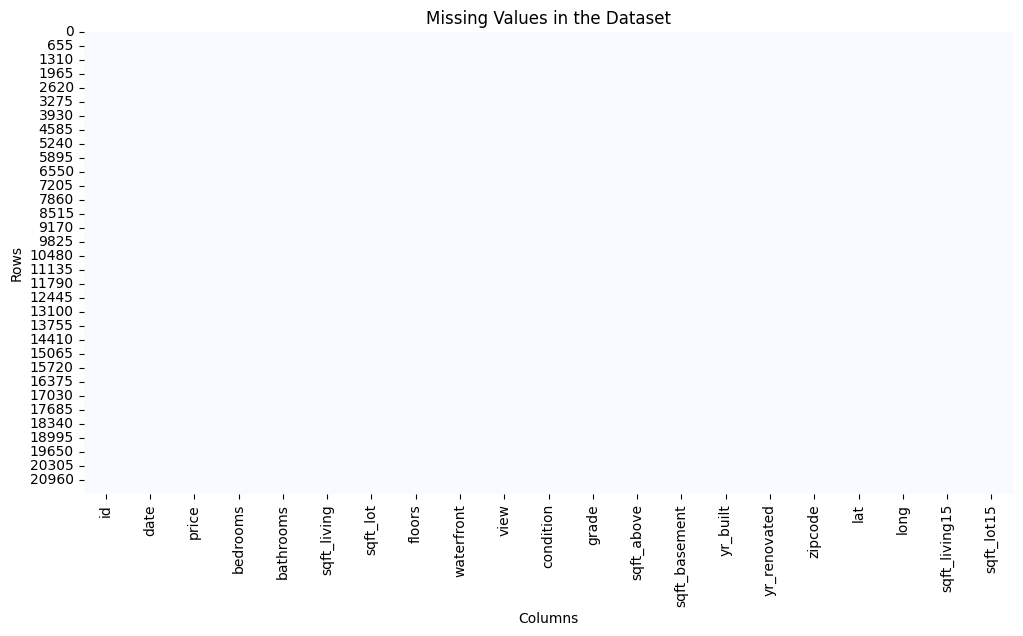

In [5]:
plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False,cmap="Blues")

plt.title("Missing Values in the Dataset")
plt.xlabel("Columns")
plt.ylabel("Rows")

plt.show()

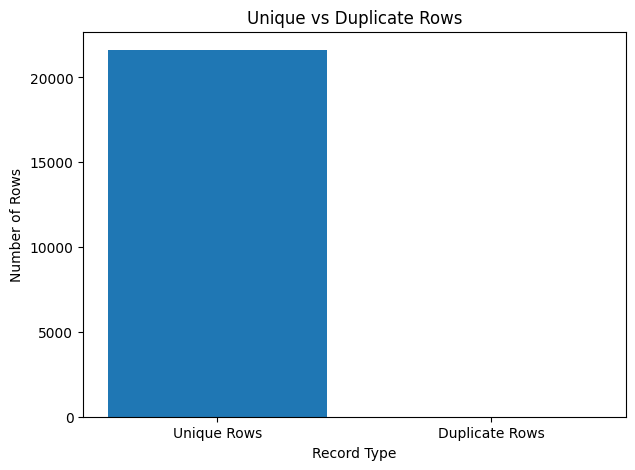

In [6]:
duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count

plt.figure(figsize=(7, 5))

plt.bar(
    ["Unique Rows", "Duplicate Rows"],
    [unique_count, duplicate_count]
)

plt.title("Unique vs Duplicate Rows")
plt.xlabel("Record Type")
plt.ylabel("Number of Rows")

plt.show()

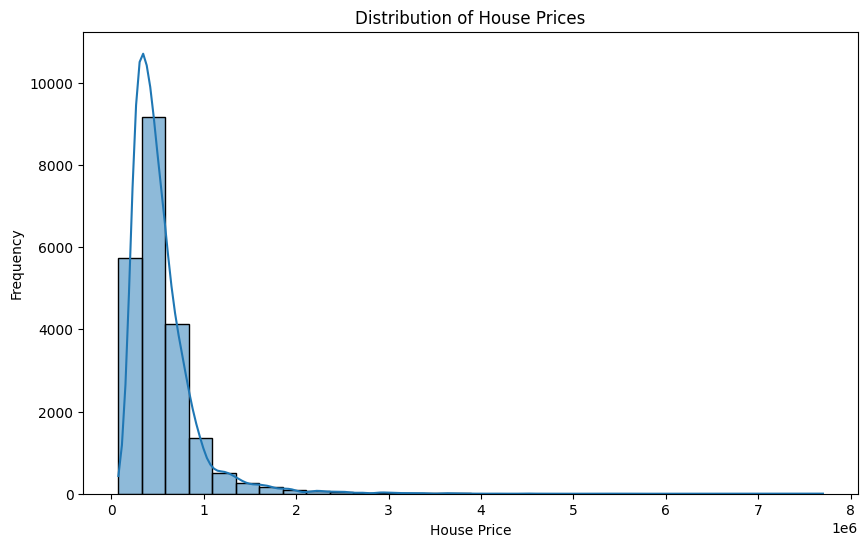

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="price", bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

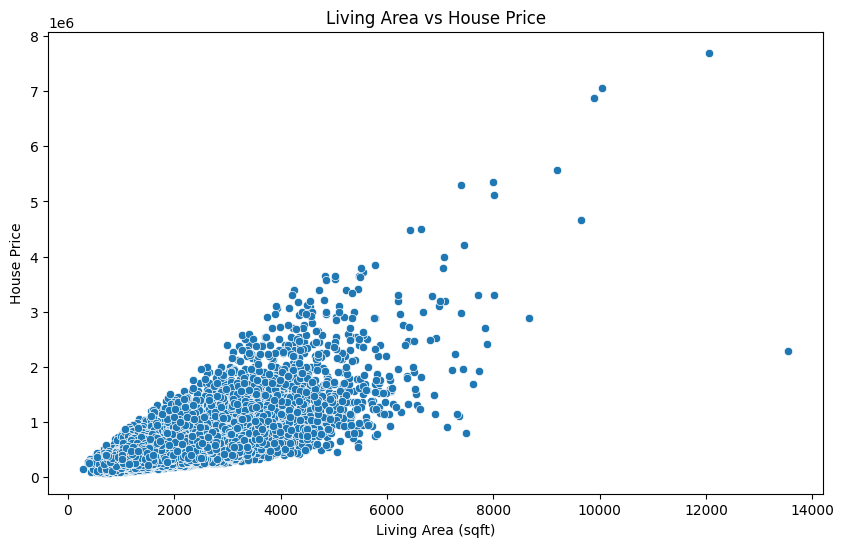

In [8]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='sqft_living', y='price')

plt.title("Living Area vs House Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("House Price")

plt.show()

### EDA Interpretation

The scatterplot shows a positive relationship between `sqft_living` and house price, where houses with larger living areas generally tend to have higher prices.

The price distribution also shows that most houses are concentrated in the lower price range, while a smaller number of properties have substantially higher prices.

# 2. Feature Engineering
### IT25200308 — Agksheya B.

This section derives meaningful new features from the existing King County House Sales variables to improve the representation of property characteristics for machine learning.

The target variable `price` is not used to construct predictor features in order to prevent data leakage.

In [9]:
# Keep the original dataframe unchanged
df_fe = df.copy()

# Convert the date column from object/string to datetime
df_fe['date'] = pd.to_datetime(
    df_fe['date'],
    format='%Y%m%dT%H%M%S'
)

print("Date converted successfully!")
print("Old type :", df['date'].dtype)
print("New type :", df_fe['date'].dtype)

print("\nExample dates:")
display(df_fe[['date']].head())

Date converted successfully!
Old type : object
New type : datetime64[ns]

Example dates:


,date
0,2014-10-13
1,2014-12-09
2,2015-02-25
3,2014-12-09
4,2015-02-18


In [10]:
# Extract useful information from the sale date

df_fe['sale_year'] = df_fe['date'].dt.year
df_fe['sale_month'] = df_fe['date'].dt.month

print("New date-based features created!")

display(
    df_fe[['date', 'sale_year', 'sale_month']].head()
)

New date-based features created!


,date,sale_year,sale_month
0,2014-10-13,2014,10
1,2014-12-09,2014,12
2,2015-02-25,2015,2
3,2014-12-09,2014,12
4,2015-02-18,2015,2


In [11]:
# Create house age at the time the property was sold
df_fe['house_age'] = df_fe['sale_year'] - df_fe['yr_built']

print("House age feature created!")

print("Minimum house age:", df_fe['house_age'].min())
print("Maximum house age:", df_fe['house_age'].max())

display(
    df_fe[['sale_year', 'yr_built', 'house_age']].head(10)
)

House age feature created!
Minimum house age: -1
Maximum house age: 115


,sale_year,yr_built,house_age
0,2014,1955,59
1,2014,1951,63
2,2015,1933,82
3,2014,1965,49
4,2015,1987,28
5,2014,2001,13
6,2014,1995,19
7,2015,1963,52
8,2015,1960,55
9,2015,2003,12


In [12]:
# Investigate records where the calculated house age is negative

negative_age = df_fe[df_fe['house_age'] < 0]

print("Number of houses with negative age:", len(negative_age))

display(
    negative_age[
        ['date', 'sale_year', 'yr_built', 'house_age', 'price', 'zipcode']
    ]
)

Number of houses with negative age: 12


,date,sale_year,yr_built,house_age,price,zipcode
1763,2014-06-25,2014,2015,-1,597326.0,98040
2687,2014-10-29,2014,2015,-1,385195.0,98144
7526,2014-12-31,2014,2015,-1,614285.0,98072
8039,2014-06-24,2014,2015,-1,455000.0,98144
14489,2014-08-26,2014,2015,-1,500000.0,98199
17098,2014-06-17,2014,2015,-1,350000.0,98122
19805,2014-08-01,2014,2015,-1,455000.0,98122
20770,2014-08-28,2014,2015,-1,357000.0,98133
20852,2014-07-09,2014,2015,-1,595000.0,98103
20963,2014-07-31,2014,2015,-1,230000.0,98144


In [13]:
# Correct logically invalid negative house ages
df_fe['house_age'] = df_fe['house_age'].clip(lower=0)

print("Negative house ages corrected!")

print("Minimum house age:", df_fe['house_age'].min())
print("Maximum house age:", df_fe['house_age'].max())

print("Number of negative ages remaining:",
      (df_fe['house_age'] < 0).sum())

Negative house ages corrected!
Minimum house age: 0
Maximum house age: 115
Number of negative ages remaining: 0


In [14]:
# Inspect the renovation-year feature before engineering new variables

never_renovated = (df_fe['yr_renovated'] == 0).sum()
renovated = (df_fe['yr_renovated'] > 0).sum()

print("Never renovated:", never_renovated)
print("Renovated:", renovated)

print("\nPercentage renovated:",
      round((renovated / len(df_fe)) * 100, 2), "%")

# Check the renovation years only for houses that were actually renovated
renovation_years = df_fe.loc[
    df_fe['yr_renovated'] > 0,
    'yr_renovated'
]

print("\nEarliest renovation year:", renovation_years.min())
print("Latest renovation year:", renovation_years.max())

# Check whether any recorded renovation happened after the sale year
invalid_renovation = df_fe[
    (df_fe['yr_renovated'] > 0) &
    (df_fe['yr_renovated'] > df_fe['sale_year'])
]

print("\nRenovations recorded after sale:",
      len(invalid_renovation))

Never renovated: 20699
Renovated: 914

Percentage renovated: 4.23 %

Earliest renovation year: 1934
Latest renovation year: 2015

Renovations recorded after sale: 6


In [15]:
# Inspect records where renovation year is after the sale year

display(
    invalid_renovation[
        [
            'date',
            'sale_year',
            'yr_built',
            'yr_renovated',
            'price',
            'zipcode'
        ]
    ]
)

,date,sale_year,yr_built,yr_renovated,price,zipcode
2295,2014-07-28,2014,1922,2015,585000.0,98112
7097,2014-10-28,2014,1940,2015,285000.0,98133
11599,2014-05-22,2014,1923,2015,850000.0,98177
14859,2014-06-06,2014,1956,2015,805000.0,98177
15687,2014-10-06,2014,1955,2015,825000.0,98177
18575,2014-07-01,2014,1945,2015,476000.0,98115


In [16]:
# A renovation is valid for prediction only if it happened
# before or during the year the house was sold
valid_renovation = (
    (df_fe['yr_renovated'] > 0) &
    (df_fe['yr_renovated'] <= df_fe['sale_year'])
)

# Feature 1: Was the house renovated by the time of sale?
df_fe['has_renovation'] = valid_renovation.astype(int)

# Feature 2: How many years had passed since renovation?
# Use 0 for houses that had not been renovated by the time of sale
df_fe['renovation_age'] = np.where(
    valid_renovation,
    df_fe['sale_year'] - df_fe['yr_renovated'],
    0
)

print("Renovation features created!")

print("Houses renovated by sale:",
      df_fe['has_renovation'].sum())

print("Minimum renovation age:",
      df_fe['renovation_age'].min())

print("Maximum renovation age:",
      df_fe['renovation_age'].max())

display(
    df_fe[
        [
            'sale_year',
            'yr_renovated',
            'has_renovation',
            'renovation_age'
        ]
    ].head(10)
)

Renovation features created!
Houses renovated by sale: 908
Minimum renovation age: 0
Maximum renovation age: 80


,sale_year,yr_renovated,has_renovation,renovation_age
0,2014,0,0,0
1,2014,1991,1,23
2,2015,0,0,0
3,2014,0,0,0
4,2015,0,0,0
5,2014,0,0,0
6,2014,0,0,0
7,2015,0,0,0
8,2015,0,0,0
9,2015,0,0,0


In [17]:
# Create a feature representing living space relative to lot size

df_fe['living_lot_ratio'] = (
    df_fe['sqft_living'] / df_fe['sqft_lot']
)

print("Living-to-lot ratio feature created!")

print("Minimum ratio:", df_fe['living_lot_ratio'].min())
print("Maximum ratio:", df_fe['living_lot_ratio'].max())

display(
    df_fe[
        ['sqft_living', 'sqft_lot', 'living_lot_ratio']
    ].head(10)
)

Living-to-lot ratio feature created!
Minimum ratio: 0.0006095498431482305
Maximum ratio: 4.653846153846154


,sqft_living,sqft_lot,living_lot_ratio
0,1180,5650,0.208850
1,2570,7242,0.354874
2,770,10000,0.077000
3,1960,5000,0.392000
4,1680,8080,0.207921
5,5420,101930,0.053174
6,1715,6819,0.251503
7,1060,9711,0.109155
8,1780,7470,0.238286
9,1890,6560,0.288110


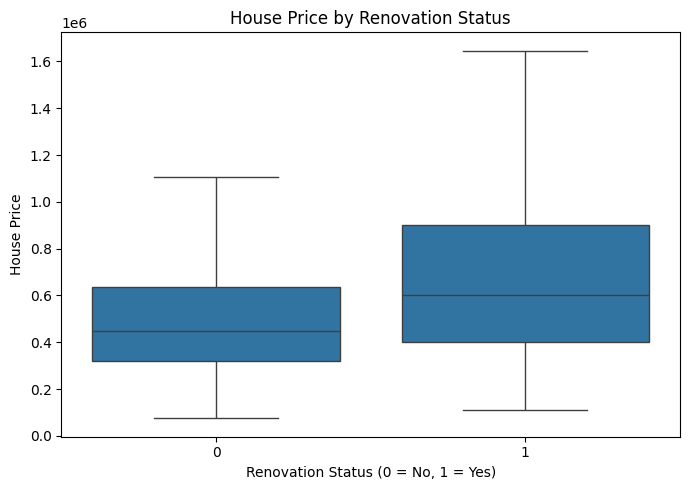

In [18]:
# ============================================================
# FEATURE ENGINEERING - RENOVATION STATUS VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df_fe,
    x='has_renovation',
    y='price',
    showfliers=False
)

plt.title('House Price by Renovation Status')
plt.xlabel('Renovation Status (0 = No, 1 = Yes)')
plt.ylabel('House Price')

plt.tight_layout()
plt.show()

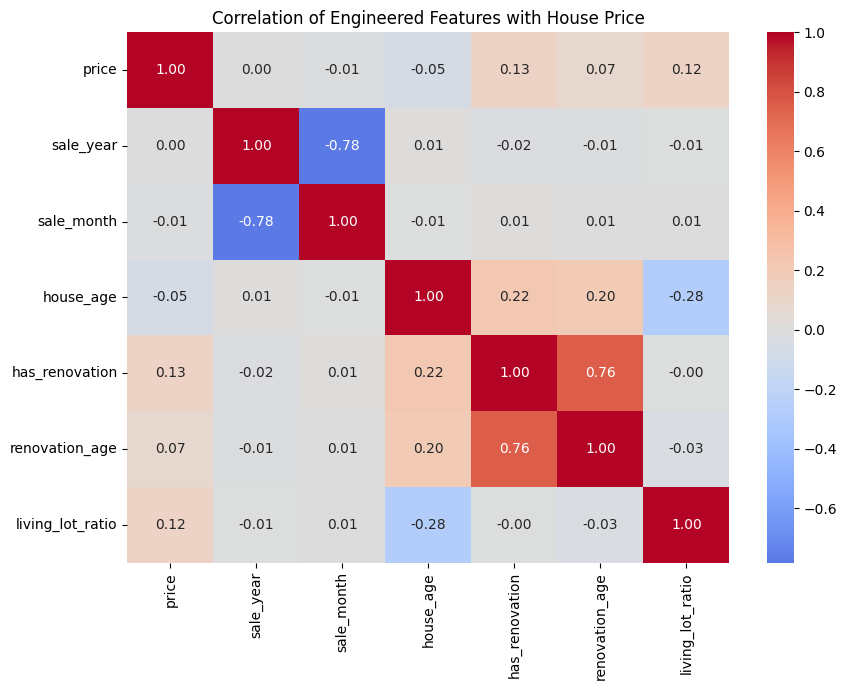

In [19]:
# ============================================================
# FEATURE ENGINEERING - EDA VISUALIZATION
# ============================================================

engineered_eda_cols = [
    'price',
    'sale_year',
    'sale_month',
    'house_age',
    'has_renovation',
    'renovation_age',
    'living_lot_ratio'
]

plt.figure(figsize=(9, 7))

sns.heatmap(
    df_fe[engineered_eda_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation of Engineered Features with House Price')
plt.tight_layout()
plt.show()

### EDA Interpretation

The engineered features show different levels of linear relationship with house price. `has_renovation` and `living_lot_ratio` show small positive correlations with price, while some engineered features have weaker linear relationships.

Weak correlation does not necessarily mean a feature is useless, because machine learning models can also capture non-linear relationships and interactions between features.

In [20]:
# ============================================================
# FEATURE ENGINEERING - SUMMARY
# ============================================================

engineered_features_pipeline = [
    'sale_year',
    'sale_month',
    'house_age',
    'has_renovation',
    'renovation_age',
    'living_lot_ratio'
]

print("Engineered features included in the combined pipeline:")
for feature in engineered_features_pipeline:
    print("-", feature)

print("\nDataset shape before Feature Engineering:", df.shape)
print("Dataset shape after Feature Engineering :", df_fe.shape)

print("\nMissing values in engineered features:")
print(df_fe[engineered_features_pipeline].isnull().sum())

display(df_fe[engineered_features_pipeline].head())

Engineered features included in the combined pipeline:
- sale_year
- sale_month
- house_age
- has_renovation
- renovation_age
- living_lot_ratio

Dataset shape before Feature Engineering: (21613, 21)
Dataset shape after Feature Engineering : (21613, 27)

Missing values in engineered features:
sale_year           0
sale_month          0
house_age           0
has_renovation      0
renovation_age      0
living_lot_ratio    0
dtype: int64


,sale_year,sale_month,house_age,has_renovation,renovation_age,living_lot_ratio
0,2014,10,59,0,0,0.208850
1,2014,12,63,1,23,0.354874
2,2015,2,82,0,0,0.077000
3,2014,12,49,0,0,0.392000
4,2015,2,28,0,0,0.207921


In [21]:
# ============================================================
# GROUP INTEGRATION - Continue Pipeline
# ============================================================

# Continue the combined pipeline using the feature-engineered dataset
df = df_fe.copy()

print("Feature-engineered dataset passed to the next preprocessing stage.")
print("Current dataset shape:", df.shape)

Feature-engineered dataset passed to the next preprocessing stage.
Current dataset shape: (21613, 27)


# 3. Outlier Analysis
### IT25103613 — Monessha S.

This section identifies potential outliers in selected numerical features using the Interquartile Range (IQR) method and visualizes their distributions using boxplots.

In [22]:
cols_to_cap = ['sqft_lot15', 'sqft_living15', 'long', 'lat',
               'sqft_basement', 'sqft_above', 'sqft_lot',
               'sqft_living', 'bathrooms', 'price', 'bedrooms']

for col in cols_to_cap:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print("Column:", col)
    print("Number of outliers:", len(outliers))
    print(outliers[col])
    print()

Column: sqft_lot15
Number of outliers: 2194
5        101930
21        20336
41        30617
49        72513
60        18900
          ...  
21520     74052
21525    107498
21532     50447
21548    151081
21576     18270
Name: sqft_lot15, Length: 2194, dtype: int64

Column: sqft_living15
Number of outliers: 544
5        4760
21       4110
173      3740
216      3836
269      3890
         ... 
21525    4650
21540    5790
21548    3860
21551    3990
21590    4560
Name: sqft_living15, Length: 544, dtype: int64

Column: long
Number of outliers: 256
99      -121.714
252     -121.711
258     -121.772
365     -121.709
403     -121.779
          ...   
21344   -121.779
21348   -121.769
21382   -121.769
21386   -121.403
21548   -121.778
Name: long, Length: 256, dtype: float64

Column: lat
Number of outliers: 2
3295     47.1559
15599    47.1593
Name: lat, dtype: float64

Column: sqft_basement
Number of outliers: 496
5        1530
10       1700
41       1620
51       1510
69       1600
         .

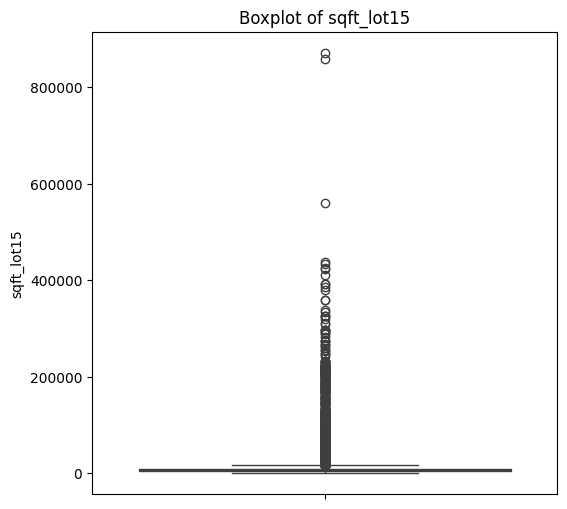

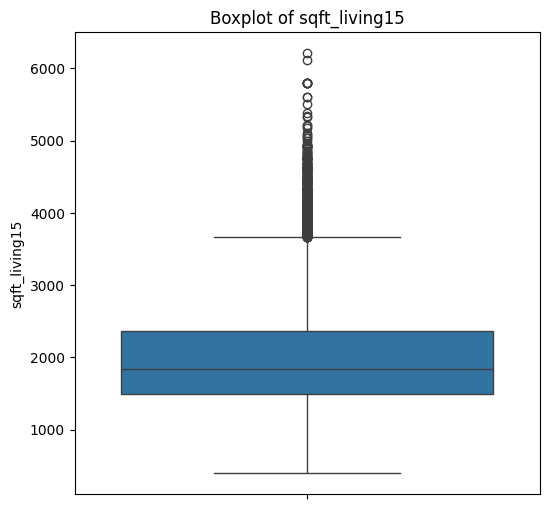

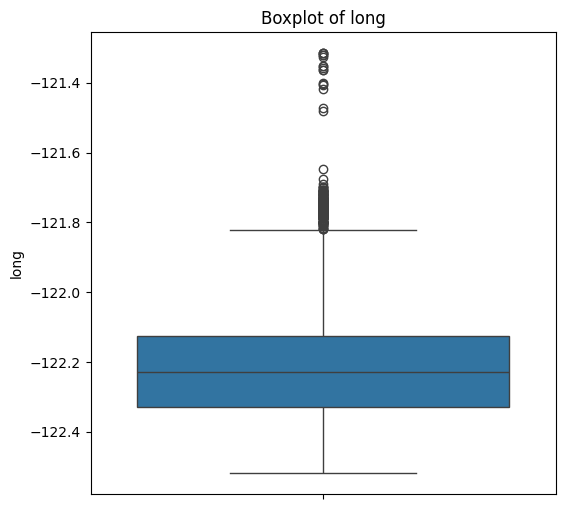

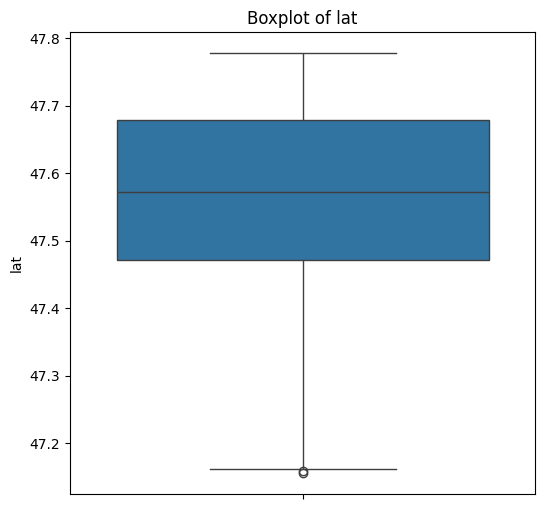

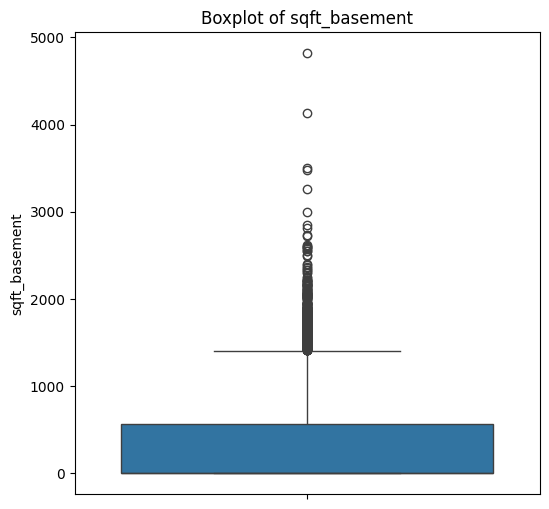

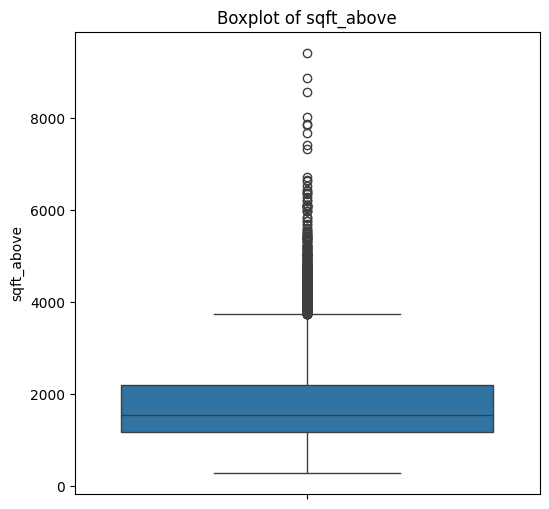

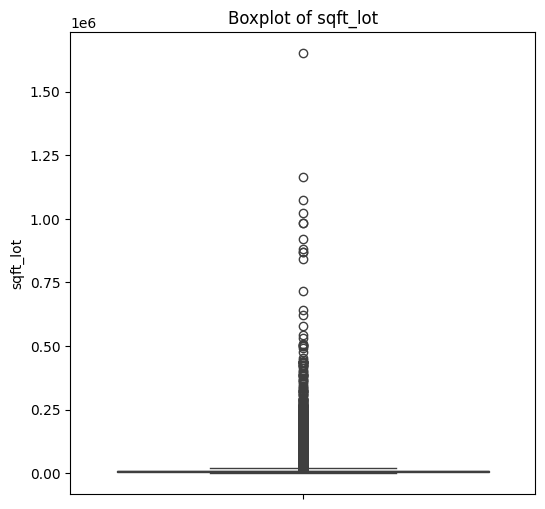

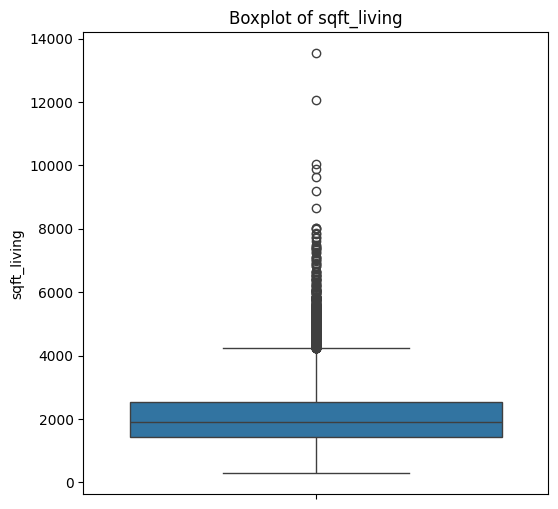

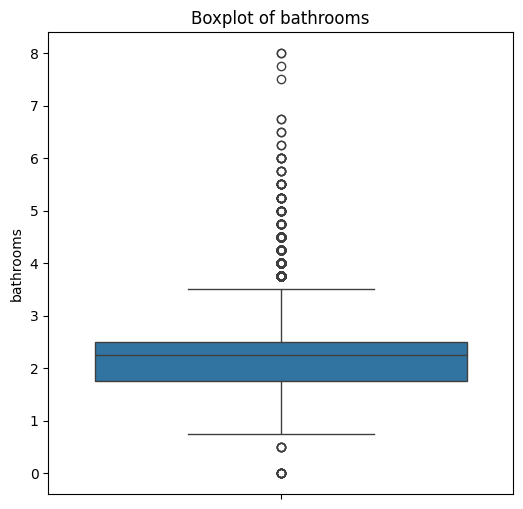

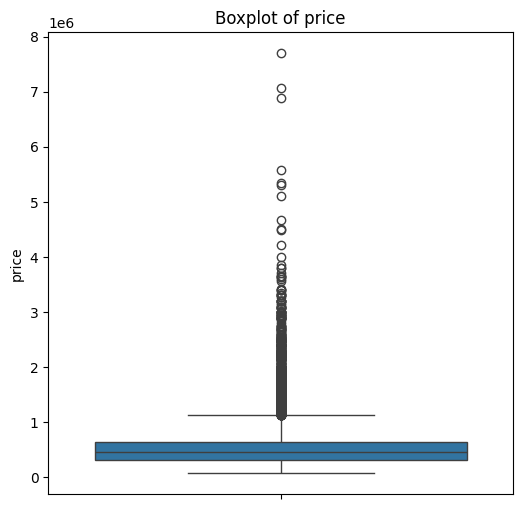

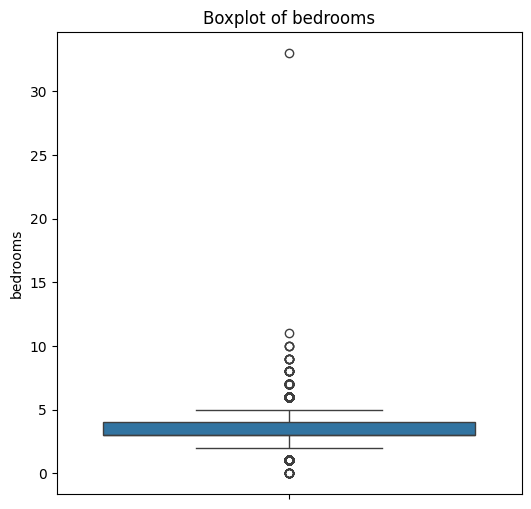

In [23]:
for col in cols_to_cap:

    plt.figure(figsize=(6, 6))

    sns.boxplot(data=df, y=col)

    plt.title(f'Boxplot of {col}')

    plt.show()

### Outlier Analysis Summary

Potential outliers were identified using the IQR method and visualized using boxplots across the selected numerical features.

No rows were removed at this stage; the analysis identifies unusual observations for consideration in the preprocessing pipeline.

# 4. Normalization and Scaling
### IT25103615 — Perera G.A.T.L.

This section examines skewness in numerical features, applies log transformation to selected right-skewed variables, and uses StandardScaler to standardize numerical features.

The existing combined dataframe is used so that preprocessing performed by previous group members is preserved.

In [24]:
numeric_cols = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
    'floors', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15'
]

skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
print(skew_vals)

sqft_lot         13.060019
sqft_lot15        9.506743
price             4.024069
bedrooms          1.974300
sqft_basement     1.577965
sqft_living       1.471555
sqft_above        1.446664
sqft_living15     1.108181
floors            0.616177
bathrooms         0.511108
dtype: float64


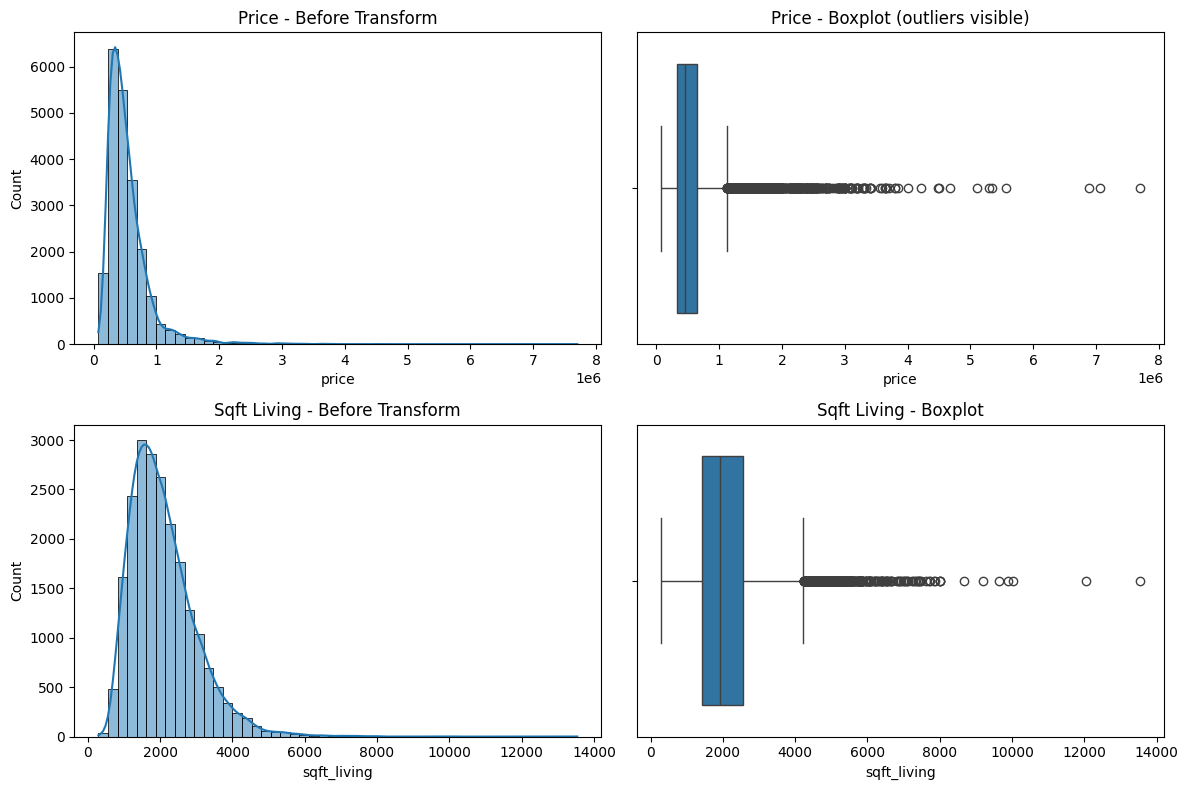

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['price'], bins=50, ax=axes[0,0], kde=True)
axes[0,0].set_title('Price - Before Transform')

sns.boxplot(x=df['price'], ax=axes[0,1])
axes[0,1].set_title('Price - Boxplot (outliers visible)')

sns.histplot(df['sqft_living'], bins=50, ax=axes[1,0], kde=True)
axes[1,0].set_title('Sqft Living - Before Transform')

sns.boxplot(x=df['sqft_living'], ax=axes[1,1])
axes[1,1].set_title('Sqft Living - Boxplot')

plt.tight_layout()
plt.show()

In [26]:
skewed_cols = ['price', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_lot15']

df_log = df.copy()
for col in skewed_cols:
    df_log[col + '_log'] = np.log1p(df_log[col])

print(df_log[[c + '_log' for c in skewed_cols]].skew().sort_values(ascending=False))

sqft_lot15_log     0.967255
sqft_lot_log       0.962893
price_log          0.428077
sqft_above_log     0.254034
sqft_living_log   -0.034727
dtype: float64


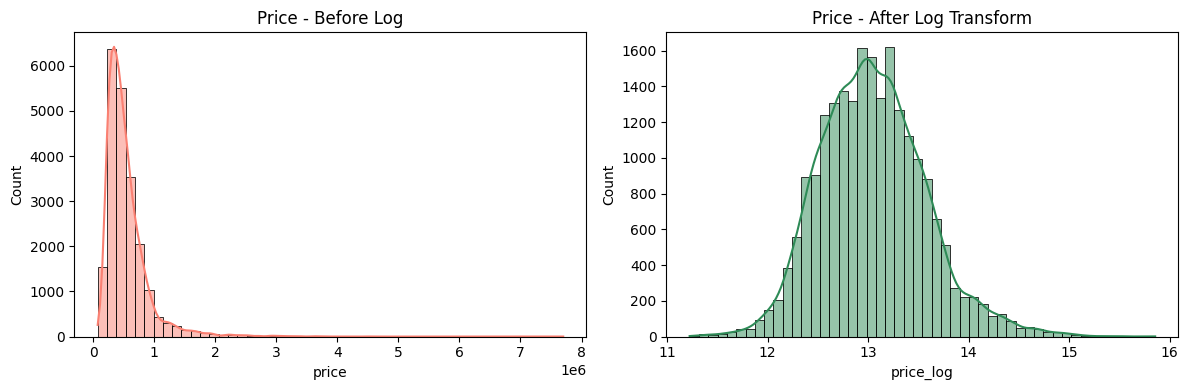

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['price'], bins=50, ax=axes[0], kde=True, color='salmon')
axes[0].set_title('Price - Before Log')

sns.histplot(df_log['price_log'], bins=50, ax=axes[1], kde=True, color='seagreen')
axes[1].set_title('Price - After Log Transform')

plt.tight_layout()
plt.show()

In [28]:
scale_cols = [
    'price_log', 'bedrooms', 'bathrooms', 'sqft_living_log',
    'sqft_lot_log', 'floors', 'sqft_above_log', 'sqft_basement',
    'yr_built', 'sqft_living15', 'sqft_lot15_log', 'lat', 'long'
]

std_scaler = StandardScaler()
df_std = df_log.copy()
df_std[scale_cols] = std_scaler.fit_transform(df_log[scale_cols])

df_std[scale_cols].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
price_log,4.878755e-15,1.000023,-3.460533,5.333331
bedrooms,2.367051e-16,1.000023,-3.624404,31.857929
bathrooms,-1.788439e-16,1.000023,-2.745920,7.641730
sqft_living_log,5.102310e-16,1.000023,-4.422521,4.622685
sqft_lot_log,-2.419652e-16,1.000023,-3.030572,5.903993
floors,-3.156068e-17,1.000023,-0.915427,3.714405
sqft_above_log,1.867340e-15,1.000023,-4.029996,4.104553
sqft_basement,6.838148e-17,1.000023,-0.658681,10.232379
yr_built,1.914681e-15,1.000023,-2.417383,1.497813
sqft_living15,8.153176e-17,1.000023,-2.316325,6.162239


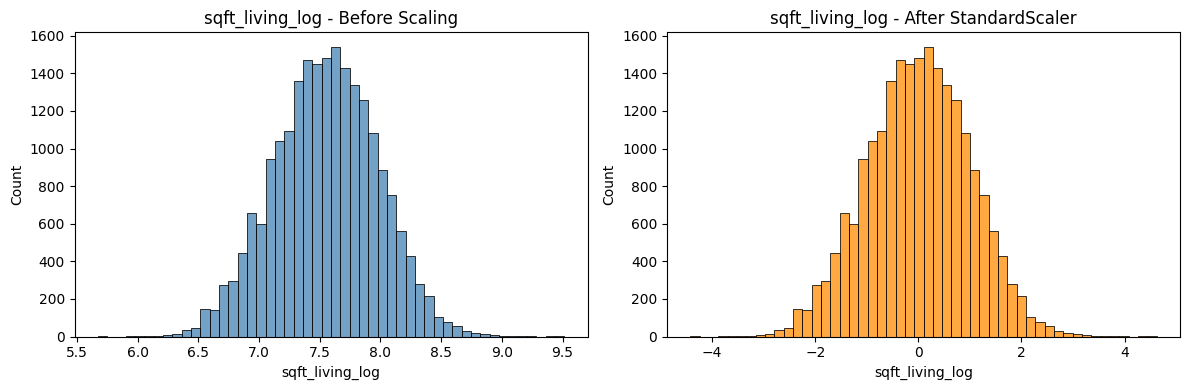

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_log['sqft_living_log'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('sqft_living_log - Before Scaling')

sns.histplot(df_std['sqft_living_log'], bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('sqft_living_log - After StandardScaler')

plt.tight_layout()
plt.show()

### Normalization and Scaling Summary

Highly right-skewed numerical variables were log-transformed to reduce skewness. Selected numerical features were then standardized using StandardScaler so that they have approximately zero mean and unit variance.

The scaled dataframe is passed to the next preprocessing stage while preserving all previous feature-engineering work.

In [30]:
# ============================================================
# GROUP INTEGRATION - Continue Pipeline
# ============================================================

# Pass the standardized dataset to the next preprocessing stage
df = df_std.copy()

print("Scaled dataset passed to the next preprocessing stage.")
print("Current dataset shape:", df.shape)

Scaled dataset passed to the next preprocessing stage.
Current dataset shape: (21613, 32)


# 5. Categorical Encoding
### IT25103618 — Shathurshigah R.

This section handles categorical information in the dataset by treating `zipcode` as a categorical feature and preparing it for machine learning using One-Hot Encoding.

Although `zipcode` is stored as an integer, its numbers represent geographic categories rather than numerical magnitude.

In [31]:
# ============================================================
# CATEGORICAL ENCODING - Prepare Zipcode
# ============================================================

df['zipcode'] = df['zipcode'].astype(str)

print("Zipcode data type:", df['zipcode'].dtype)
print("Number of unique zipcodes:", df['zipcode'].nunique())

display(df[['zipcode']].head())

Zipcode data type: object
Number of unique zipcodes: 70


,zipcode
0,98178
1,98125
2,98028
3,98136
4,98074


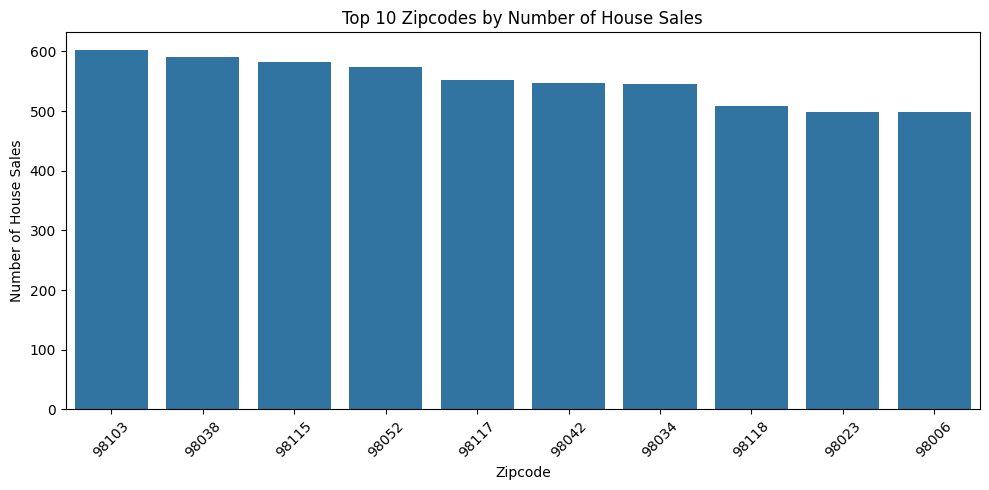

In [32]:
# ============================================================
# CATEGORICAL ENCODING - EDA VISUALIZATION
# ============================================================

top_zipcodes = df['zipcode'].value_counts().head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_zipcodes.index,
    y=top_zipcodes.values
)

plt.title('Top 10 Zipcodes by Number of House Sales')
plt.xlabel('Zipcode')
plt.ylabel('Number of House Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### EDA Interpretation

The dataset contains many different zipcode categories, and some zipcodes appear more frequently than others.

Since zipcode represents geographic categories rather than numerical magnitude, it is treated as a categorical feature. One-Hot Encoding prevents the model from incorrectly interpreting zipcode values as having a numerical order.

In [33]:
# ============================================================
# GROUP INTEGRATION - Apply One-Hot Encoding
# ============================================================

# Create the One-Hot Encoder
zipcode_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Encode zipcode
zipcode_encoded = zipcode_encoder.fit_transform(df[['zipcode']])

# Get meaningful column names
zipcode_columns = zipcode_encoder.get_feature_names_out(['zipcode'])

# Convert encoded values into a DataFrame
zipcode_encoded_df = pd.DataFrame(
    zipcode_encoded,
    columns=zipcode_columns,
    index=df.index
)

# Remove the original zipcode column
df_encoded = df.drop(columns=['zipcode'])

# Add the new encoded zipcode columns
df_encoded = pd.concat(
    [df_encoded, zipcode_encoded_df],
    axis=1
)

print("One-Hot Encoding completed successfully!")
print("Number of zipcode categories:", len(zipcode_columns))
print("Shape before encoding:", df.shape)
print("Shape after encoding :", df_encoded.shape)

display(df_encoded[zipcode_columns[:5]].head())

One-Hot Encoding completed successfully!
Number of zipcode categories: 70
Shape before encoding: (21613, 32)
Shape after encoding : (21613, 101)


,zipcode_98001,zipcode_98002,zipcode_98003,zipcode_98004,zipcode_98005
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


In [34]:
# ============================================================
# FINAL PIPELINE VALIDATION
# ============================================================

print("Final encoded dataset shape:", df_encoded.shape)

print("\nTotal missing values:")
print(df_encoded.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_encoded.duplicated().sum())

print("\nData types:")
print(df_encoded.dtypes.value_counts())

print("\nFirst 5 rows:")
display(df_encoded.head())

Final encoded dataset shape: (21613, 101)

Total missing values:
0

Duplicate rows:
0

Data types:
float64           85
int64             13
int32              2
datetime64[ns]     1
Name: count, dtype: int64

First 5 rows:


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,house_age,has_renovation,renovation_age,living_lot_ratio,price_log,sqft_living_log,sqft_lot_log,sqft_above_log,sqft_lot15_log,zipcode_98001,zipcode_98002,zipcode_98003,zipcode_98004,zipcode_98005,zipcode_98006,zipcode_98007,zipcode_98008,zipcode_98010,zipcode_98011,zipcode_98014,zipcode_98019,zipcode_98022,zipcode_98023,zipcode_98024,zipcode_98027,zipcode_98028,zipcode_98029,zipcode_98030,zipcode_98031,zipcode_98032,zipcode_98033,zipcode_98034,zipcode_98038,zipcode_98039,zipcode_98040,zipcode_98042,zipcode_98045,zipcode_98052,zipcode_98053,zipcode_98055,zipcode_98056,zipcode_98058,zipcode_98059,zipcode_98065,zipcode_98070,zipcode_98072,zipcode_98074,zipcode_98075,zipcode_98077,zipcode_98092,zipcode_98102,zipcode_98103,zipcode_98105,zipcode_98106,zipcode_98107,zipcode_98108,zipcode_98109,zipcode_98112,zipcode_98115,zipcode_98116,zipcode_98117,zipcode_98118,zipcode_98119,zipcode_98122,zipcode_98125,zipcode_98126,zipcode_98133,zipcode_98136,zipcode_98144,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,7129300520,2014-10-13,221900.0,-0.398737,-1.447464,1180,5650,-0.915427,0,0,3,7,1180,-0.658681,-0.544898,0,-0.352572,-0.306079,-0.943355,5650,2014,10,59,0,0,0.208850,-1.400936,-1.123053,-0.388517,-0.752147,-0.395577,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,6414100192,2014-12-09,538000.0,-0.398737,0.175607,2570,7242,0.936506,0,0,3,7,2170,0.245141,-0.681079,1991,1.161568,-0.746341,-0.432686,7639,2014,12,63,1,23,0.354874,0.280624,0.709313,-0.113429,0.672503,-0.024606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5631500400,2015-02-25,180000.0,-1.473959,-1.447464,770,10000,-0.915427,0,0,3,6,770,-0.658681,-1.293892,0,1.283537,-0.135655,1.070140,8062,2015,2,82,0,0,0.077000,-1.798279,-2.127474,0.244170,-1.749987,0.041685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2487200875,2014-12-09,604000.0,0.676485,1.149449,1960,5000,-0.915427,0,0,5,7,1050,1.397515,-0.204446,0,-0.283288,-1.271816,-0.914174,5000,2014,12,49,0,0,0.392000,0.500335,0.071368,-0.523948,-1.025036,-0.545895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1954400510,2015-02-18,510000.0,-0.398737,-0.149007,1680,8080,-0.915427,0,0,3,8,1680,-0.658681,0.544548,0,0.409550,1.199335,-0.272190,7503,2015,2,28,0,0,0.207921,0.179141,-0.291522,0.007910,0.073935,-0.046701,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
# ============================================================
# FINAL MODEL-READY DATASET
# ============================================================

# Target variable
y = df_encoded['price'].copy()

# Columns that should NOT be used as predictors
columns_to_remove = [
    'price',          # target variable
    'price_log',      # derived from target -> target leakage
    'id',             # identifier only
    'date',           # already represented by sale_year and sale_month
    'yr_renovated',   # represented safely by has_renovation and renovation_age

    # Raw versions replaced by log-transformed versions
    'sqft_living',
    'sqft_lot',
    'sqft_above',
    'sqft_lot15'
]

X = df_encoded.drop(columns=columns_to_remove)

print("Final feature matrix X:", X.shape)
print("Target y:", y.shape)

print("\nMissing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

print("\nRemaining non-numeric columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

display(X.head())

Final feature matrix X: (21613, 92)
Target y: (21613,)

Missing values in X: 0
Missing values in y: 0

Remaining non-numeric columns:
[]


,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_basement,yr_built,lat,long,sqft_living15,sale_year,sale_month,house_age,has_renovation,renovation_age,living_lot_ratio,sqft_living_log,sqft_lot_log,sqft_above_log,sqft_lot15_log,zipcode_98001,zipcode_98002,zipcode_98003,zipcode_98004,zipcode_98005,zipcode_98006,zipcode_98007,zipcode_98008,zipcode_98010,zipcode_98011,zipcode_98014,zipcode_98019,zipcode_98022,zipcode_98023,zipcode_98024,zipcode_98027,zipcode_98028,zipcode_98029,zipcode_98030,zipcode_98031,zipcode_98032,zipcode_98033,zipcode_98034,zipcode_98038,zipcode_98039,zipcode_98040,zipcode_98042,zipcode_98045,zipcode_98052,zipcode_98053,zipcode_98055,zipcode_98056,zipcode_98058,zipcode_98059,zipcode_98065,zipcode_98070,zipcode_98072,zipcode_98074,zipcode_98075,zipcode_98077,zipcode_98092,zipcode_98102,zipcode_98103,zipcode_98105,zipcode_98106,zipcode_98107,zipcode_98108,zipcode_98109,zipcode_98112,zipcode_98115,zipcode_98116,zipcode_98117,zipcode_98118,zipcode_98119,zipcode_98122,zipcode_98125,zipcode_98126,zipcode_98133,zipcode_98136,zipcode_98144,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199
0,-0.398737,-1.447464,-0.915427,0,0,3,7,-0.658681,-0.544898,-0.352572,-0.306079,-0.943355,2014,10,59,0,0,0.208850,-1.123053,-0.388517,-0.752147,-0.395577,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,-0.398737,0.175607,0.936506,0,0,3,7,0.245141,-0.681079,1.161568,-0.746341,-0.432686,2014,12,63,1,23,0.354874,0.709313,-0.113429,0.672503,-0.024606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-1.473959,-1.447464,-0.915427,0,0,3,6,-0.658681,-1.293892,1.283537,-0.135655,1.070140,2015,2,82,0,0,0.077000,-2.127474,0.244170,-1.749987,0.041685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.676485,1.149449,-0.915427,0,0,5,7,1.397515,-0.204446,-0.283288,-1.271816,-0.914174,2014,12,49,0,0,0.392000,0.071368,-0.523948,-1.025036,-0.545895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.398737,-0.149007,-0.915427,0,0,3,8,-0.658681,0.544548,0.409550,1.199335,-0.272190,2015,2,28,0,0,0.207921,-0.291522,0.007910,0.073935,-0.046701,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
# ============================================================
# SAVE FINAL PROCESSED DATASET
# ============================================================

final_processed_data = X.copy()
final_processed_data['price'] = y.values

output_filename = 'final_processed_house_data.csv'

final_processed_data.to_csv(
    output_filename,
    index=False
)

print("Final processed dataset saved successfully!")
print("Saved file:", output_filename)
print("Final shape:", final_processed_data.shape)

display(final_processed_data.head())

Final processed dataset saved successfully!
Saved file: final_processed_house_data.csv
Final shape: (21613, 93)


,bedrooms,bathrooms,floors,waterfront,view,condition,grade,sqft_basement,yr_built,lat,long,sqft_living15,sale_year,sale_month,house_age,has_renovation,renovation_age,living_lot_ratio,sqft_living_log,sqft_lot_log,sqft_above_log,sqft_lot15_log,zipcode_98001,zipcode_98002,zipcode_98003,zipcode_98004,zipcode_98005,zipcode_98006,zipcode_98007,zipcode_98008,zipcode_98010,zipcode_98011,zipcode_98014,zipcode_98019,zipcode_98022,zipcode_98023,zipcode_98024,zipcode_98027,zipcode_98028,zipcode_98029,zipcode_98030,zipcode_98031,zipcode_98032,zipcode_98033,zipcode_98034,zipcode_98038,zipcode_98039,zipcode_98040,zipcode_98042,zipcode_98045,zipcode_98052,zipcode_98053,zipcode_98055,zipcode_98056,zipcode_98058,zipcode_98059,zipcode_98065,zipcode_98070,zipcode_98072,zipcode_98074,zipcode_98075,zipcode_98077,zipcode_98092,zipcode_98102,zipcode_98103,zipcode_98105,zipcode_98106,zipcode_98107,zipcode_98108,zipcode_98109,zipcode_98112,zipcode_98115,zipcode_98116,zipcode_98117,zipcode_98118,zipcode_98119,zipcode_98122,zipcode_98125,zipcode_98126,zipcode_98133,zipcode_98136,zipcode_98144,zipcode_98146,zipcode_98148,zipcode_98155,zipcode_98166,zipcode_98168,zipcode_98177,zipcode_98178,zipcode_98188,zipcode_98198,zipcode_98199,price
0,-0.398737,-1.447464,-0.915427,0,0,3,7,-0.658681,-0.544898,-0.352572,-0.306079,-0.943355,2014,10,59,0,0,0.208850,-1.123053,-0.388517,-0.752147,-0.395577,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,221900.0
1,-0.398737,0.175607,0.936506,0,0,3,7,0.245141,-0.681079,1.161568,-0.746341,-0.432686,2014,12,63,1,23,0.354874,0.709313,-0.113429,0.672503,-0.024606,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,538000.0
2,-1.473959,-1.447464,-0.915427,0,0,3,6,-0.658681,-1.293892,1.283537,-0.135655,1.070140,2015,2,82,0,0,0.077000,-2.127474,0.244170,-1.749987,0.041685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,180000.0
3,0.676485,1.149449,-0.915427,0,0,5,7,1.397515,-0.204446,-0.283288,-1.271816,-0.914174,2014,12,49,0,0,0.392000,0.071368,-0.523948,-1.025036,-0.545895,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,604000.0
4,-0.398737,-0.149007,-0.915427,0,0,3,8,-0.658681,0.544548,0.409550,1.199335,-0.272190,2015,2,28,0,0,0.207921,-0.291522,0.007910,0.073935,-0.046701,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,510000.0


# Combined Preprocessing Pipeline — Final Summary

The group preprocessing pipeline was successfully completed using the King County House Sales dataset.

### Integrated Contributions

- **IT25103558 — Vipusha V.**
  - Missing-value inspection
  - Duplicate-record inspection
  - Basic EDA

- **IT25200308 — Agksheya B.**
  - Feature Engineering
  - Sale year and month
  - House age
  - Renovation-based features
  - Living-to-lot ratio

- **IT25103613 — Monessha S.**
  - Outlier identification using the IQR method
  - Boxplot-based outlier visualization

- **IT25103615 — Perera G.A.T.L.**
  - Skewness analysis
  - Log transformation
  - StandardScaler standardization

- **IT25103618 — Shathurshigah R.**
  - Categorical treatment of zipcode
  - One-Hot Encoding

### Final Output

- Original dataset: **21,613 rows × 21 columns**
- Final predictor matrix: **21,613 rows × 92 features**
- Final processed dataset including target: **21,613 rows × 93 columns**
- Missing values: **0**
- Original dataset duplicate rows: **0**
- All model predictors are numeric.

The final processed dataset is saved as:

`final_processed_house_data.csv`

In [37]:
from google.colab import files

files.download('final_processed_house_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>